In [1]:

!pip install open3d -q          
!pip install timm -q            
!pip install torchinfo -q       

import warnings
warnings.filterwarnings('ignore')
print('✅ Kurulum tamamlandı')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 113.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 re

In [2]:

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchinfo import summary
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    import open3d as o3d
    OPEN3D_AVAILABLE = True
except:
    OPEN3D_AVAILABLE = False
    print('⚠️  open3d yüklenemedi, LiDAR için fallback kullanılacak')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU modu"}')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
✅ Device: cuda
GPU: Tesla T4


In [3]:

BASE_DIR    = '/kaggle/input/datasets/mustafabalam/scenario-32'
CSV_PATH    = f'{BASE_DIR}/scenario32_dev.csv'
UNIT1_DIR   = f'{BASE_DIR}/unit1'
UNIT2_DIR   = f'{BASE_DIR}/unit2'

NUM_BEAMS   = 64
BATCH_SIZE  = 32
NUM_EPOCHS  = 60
LR          = 1e-4
SEQ_LEN     = 1      # LSTM yok, tek frame
LIDAR_NPTS  = 1024
RADAR_SIZE  = (256, 250)
IMG_SIZE    = 224

# CSV'yi yükle
df = pd.read_csv(CSV_PATH)
print(f'✅ CSV yüklendi: {df.shape}')
print(f'Kolonlar: {list(df.columns)}')
df.head(3)

✅ CSV yüklendi: (3235, 20)
Kolonlar: ['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_lidar', 'unit1_radar', 'unit1_loc', 'unit2_loc', 'unit1_beam', 'unit1_max_pwr', 'time_stamp', 'seq_index', 'unit2_spd_over_grnd_kmph', 'unit2_num_sats', 'unit2_altitude', 'unit2_geo_sep', 'unit2_mode_fix_type', 'unit2_pdop', 'unit2_hdop', 'unit2_vdop', 'unit2_interpolated_position']


,index,unit1_rgb,unit1_pwr_60ghz,unit1_lidar,unit1_radar,unit1_loc,unit2_loc,unit1_beam,unit1_max_pwr,time_stamp,seq_index,unit2_spd_over_grnd_kmph,unit2_num_sats,unit2_altitude,unit2_geo_sep,unit2_mode_fix_type,unit2_pdop,unit2_hdop,unit2_vdop,unit2_interpolated_position
0,1,./unit1/camera_data/image_1.jpg,./unit1/mmWave_data/mmWave_power_1.txt,./unit1/lidar_data/lidar_data_1.ply,./unit1/radar_data/radar_data_1.npy,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/GPS_location_1.txt,3,0.174674,01:22:30-405771,1,5.820,12.0,356.810,-27.749,3.0,1.09,0.58,0.92,0.0
1,2,./unit1/camera_data/image_2.jpg,./unit1/mmWave_data/mmWave_power_2.txt,./unit1/lidar_data/lidar_data_2.ply,./unit1/radar_data/radar_data_2.npy,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/GPS_location_2.txt,3,0.254461,01:22:30-497819,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,3,./unit1/camera_data/image_3.jpg,./unit1/mmWave_data/mmWave_power_3.txt,./unit1/lidar_data/lidar_data_3.ply,./unit1/radar_data/radar_data_3.npy,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/GPS_location_3.txt,3,0.189701,01:22:30-592039,1,5.862,12.0,356.814,-27.749,3.0,1.09,0.58,0.92,0.0


In [4]:

import glob, numpy as np

# CSV'den ilk geçerli dosyaları bul
radar_col  = next((c for c in df.columns if 'radar' in c.lower()), None)
lidar_col  = next((c for c in df.columns if 'lidar' in c.lower()), None)

if radar_col:
    radar_path = os.path.join(BASE_DIR, str(df[radar_col].iloc[0]).lstrip('/'))
    arr = np.load(radar_path)
    print(f'✅ Radar shape : {arr.shape} | dtype: {arr.dtype}')
    RADAR_SIZE = (arr.shape[-2], arr.shape[-1]) if arr.ndim >= 2 else (64, 64)
    print(f'   → RADAR_SIZE ayarlandı: {RADAR_SIZE}')

if lidar_col:
    lidar_path = os.path.join(BASE_DIR, str(df[lidar_col].iloc[0]).lstrip('/'))
    import open3d as o3d
    pcd = o3d.io.read_point_cloud(lidar_path)
    pts = np.asarray(pcd.points)
    print(f'✅ LiDAR nokta sayısı: {pts.shape[0]} | shape: {pts.shape}')
    # LIDAR_NPTS zaten 1024 (örnekleme yapıyoruz, orijinal boyut önemli değil)

print([c for c in df.columns if 'power' in c.lower()])

✅ Radar shape : (4, 256, 250) | dtype: complex64
   → RADAR_SIZE ayarlandı: (256, 250)
✅ LiDAR nokta sayısı: 18131 | shape: (18131, 3)
[]


=== CSV Detayları ===
index                            int64
unit1_rgb                       object
unit1_pwr_60ghz                 object
unit1_lidar                     object
unit1_radar                     object
unit1_loc                       object
unit2_loc                       object
unit1_beam                       int64
unit1_max_pwr                  float64
time_stamp                      object
seq_index                        int64
unit2_spd_over_grnd_kmph       float64
unit2_num_sats                 float64
unit2_altitude                 float64
unit2_geo_sep                  float64
unit2_mode_fix_type            float64
unit2_pdop                     float64
unit2_hdop                     float64
unit2_vdop                     float64
unit2_interpolated_position    float64
dtype: object

Null değerler:
index                            0
unit1_rgb                        0
unit1_pwr_60ghz                  0
unit1_lidar                      0
unit1_radar                 

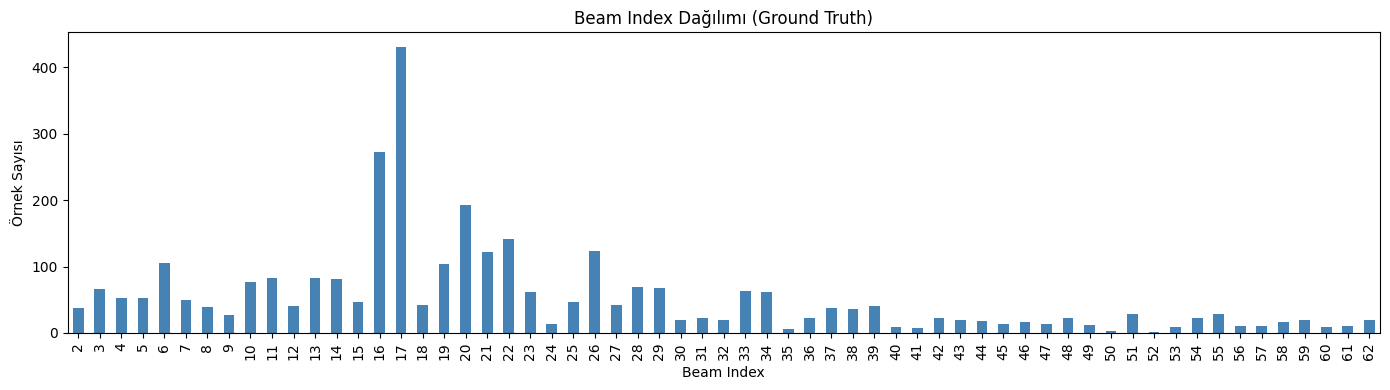

Top-1 beam: 17 | Class sayısı: 61


In [5]:

"""
DeepSense 6G CSV genellikle şu kolonları içerir:
  unit1_rgb, unit1_lidar, unit1_radar, unit1_gps
  unit2_beam_index (veya 'beam_index') → HEDEF
  unit1_beam_power_1 ... unit1_beam_power_64
"""

print('=== CSV Detayları ===')
print(df.dtypes)
print('\nNull değerler:')
print(df.isnull().sum())

# Beam sütunlarını bul
beam_cols = [c for c in df.columns if 'beam' in c.lower() or 'power' in c.lower()]
print(f'\nBeam/Power kolonları: {beam_cols[:5]}...')

# Label: En güçlü beam = argmax(power vektörü)
# Eğer CSV'de 'unit1_beam_index' varsa direkt kullan
power_cols = [c for c in df.columns if re.search(r'unit1.*power', c, re.I)]

if 'unit1_beam_index' in df.columns:
    df['label'] = df['unit1_beam_index'].astype(int)
    print('\n✅ Label: unit1_beam_index kullanılıyor')
elif len(power_cols) >= 64:
    power_arr = df[power_cols[:64]].values
    df['label'] = np.argmax(power_arr, axis=1)
    print(f'\n✅ Label: argmax(power_1..64) → {df["label"].nunique()} unique beam')
else:
    # Fallback: son beam kolonu
    target_col = beam_cols[0] if beam_cols else df.columns[-1]
    df['label'] = df[target_col].astype(int)
    print(f'\n⚠️  Label: {target_col} kullanılıyor')

# Beam dağılımı
plt.figure(figsize=(14, 4))
df['label'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Beam Index Dağılımı (Ground Truth)')
plt.xlabel('Beam Index'); plt.ylabel('Örnek Sayısı')
plt.tight_layout(); plt.show()
print(f'Top-1 beam: {df["label"].value_counts().index[0]} | Class sayısı: {df["label"].nunique()}')

In [6]:

def get_rgb_path(row):
    """CSV'deki relative path'i absolute'a çevir"""
    for col in df.columns:
        if 'rgb' in col.lower() or 'image' in col.lower() or 'img' in col.lower():
            rel = str(row[col])
            # DeepSense formatı: 'unit1/rgb_images/img_00001.jpg'
            return os.path.join(BASE_DIR, rel.lstrip('/'))
    return None

def get_lidar_path(row):
    for col in df.columns:
        if 'lidar' in col.lower() or 'ply' in col.lower():
            rel = str(row[col])
            return os.path.join(BASE_DIR, rel.lstrip('/'))
    return None

def get_radar_path(row):
    for col in df.columns:
        if 'radar' in col.lower() or 'npy' in col.lower():
            rel = str(row[col])
            return os.path.join(BASE_DIR, rel.lstrip('/'))
    return None

def get_gps(row):
    """GPS lat/lon döndür"""
    lat_col = next((c for c in df.columns if 'lat' in c.lower()), None)
    lon_col = next((c for c in df.columns if 'lon' in c.lower() or 'lng' in c.lower()), None)
    if lat_col and lon_col:
        return float(row[lat_col]), float(row[lon_col])
    return 0.0, 0.0

# --- Test
sample_row = df.iloc[0]
print('RGB path:', get_rgb_path(sample_row))
print('LiDAR path:', get_lidar_path(sample_row))
print('Radar path:', get_radar_path(sample_row))
print('GPS:', get_gps(sample_row))

RGB path: /kaggle/input/datasets/mustafabalam/scenario-32/./unit1/camera_data/image_1.jpg
LiDAR path: /kaggle/input/datasets/mustafabalam/scenario-32/./unit1/lidar_data/lidar_data_1.ply
Radar path: /kaggle/input/datasets/mustafabalam/scenario-32/./unit1/radar_data/radar_data_1.npy
GPS: (0.0, 0.0)


In [7]:


def read_lidar_ply(path, n_points=LIDAR_NPTS):
    """
    PLY formatındaki LiDAR nokta bulutunu oku.
    Çıktı: (n_points, 3) numpy array [x, y, z]
    """
    if path is None or not os.path.exists(str(path)):
        return np.zeros((n_points, 3), dtype=np.float32)
    
    if OPEN3D_AVAILABLE:
        pcd = o3d.io.read_point_cloud(str(path))
        pts = np.asarray(pcd.points, dtype=np.float32)
    else:
        # open3d yoksa manuel oku
        pts = []
        with open(path, 'rb') as f:
            header_done = False
            for line in f:
                try:
                    decoded = line.decode('ascii').strip()
                except:
                    break
                if decoded == 'end_header':
                    header_done = True
                    continue
                if header_done:
                    vals = decoded.split()
                    if len(vals) >= 3:
                        pts.append([float(v) for v in vals[:3]])
        pts = np.array(pts, dtype=np.float32) if pts else np.zeros((1, 3), dtype=np.float32)
    
    if len(pts) == 0:
        return np.zeros((n_points, 3), dtype=np.float32)
    
    # Random örnekleme veya padding
    if len(pts) >= n_points:
        idx = np.random.choice(len(pts), n_points, replace=False)
    else:
        idx = np.random.choice(len(pts), n_points, replace=True)
    pts = pts[idx]
    
    # Normalize: merkeze al
    pts -= pts.mean(axis=0)
    dist = np.max(np.sqrt(np.sum(pts**2, axis=1)))
    if dist > 0:
        pts /= dist
    return pts  # (n_points, 3)


def read_radar_npy(path, size=RADAR_SIZE):
    if path is None or not os.path.exists(str(path)):
        return np.zeros((4, size[0], size[1]), dtype=np.float32)
    
    arr = np.load(str(path)).astype(np.complex64)  # (4, 256, 250)
    arr = np.abs(arr)                               # magnitude al
    arr = 20 * np.log10(arr + 1e-10)               # dB'e çevir
    
    # Her kanalı normalize et
    for i in range(arr.shape[0]):
        mn, mx = arr[i].min(), arr[i].max()
        if mx > mn:
            arr[i] = (arr[i] - mn) / (mx - mn)
    
    # Resize
    resized = np.zeros((4, size[0], size[1]), dtype=np.float32)
    for i in range(arr.shape[0]):
        img = Image.fromarray(arr[i].astype(np.float32))
        img = img.resize((size[1], size[0]), Image.BILINEAR)
        resized[i] = np.array(img)
    
    return resized  # (4, 256, 250)



print('✅ LiDAR ve Radar okuma fonksiyonları hazır')

✅ LiDAR ve Radar okuma fonksiyonları hazır


In [8]:
class DeepSense6GDataset(Dataset):
    def __init__(self, dataframe, augment=False, seq_len=1):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment
        self.seq_len = seq_len
        if augment:
            self.rgb_transform = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.ToTensor(),
                transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
            ])
        else:
            self.rgb_transform = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
            ])
        gps_data = [get_gps(self.df.iloc[i]) for i in range(len(self.df))]
        gps_arr = np.array(gps_data, dtype=np.float32)
        self.gps_mean = gps_arr.mean(axis=0)
        self.gps_std = gps_arr.std(axis=0) + 1e-8

    def load_single(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(get_rgb_path(row)).convert('RGB')
            rgb = self.rgb_transform(img)
        except:
            rgb = torch.zeros(3, IMG_SIZE, IMG_SIZE)
        lidar = torch.from_numpy(read_lidar_ply(get_lidar_path(row)).T)
        radar = torch.from_numpy(read_radar_npy(get_radar_path(row)))
        lat, lon = get_gps(row)
        gps = torch.from_numpy(
            (np.array([lat, lon], dtype=np.float32) - self.gps_mean) / self.gps_std
        )
        return rgb, lidar, radar, gps

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        indices = [max(0, idx - self.seq_len + 1 + i) for i in range(self.seq_len)]
        rgbs, lidars, radars, gpss = [], [], [], []
        for i in indices:
            rgb, lidar, radar, gps = self.load_single(i)
            rgbs.append(rgb)
            lidars.append(lidar)
            radars.append(radar)
            gpss.append(gps)
        if self.seq_len == 1:
            return {
                'rgb':   rgbs[0],
                'lidar': lidars[0],
                'radar': radars[0],
                'gps':   gpss[0],
                'label': torch.tensor(int(self.df.iloc[idx]['label']), dtype=torch.long)
            }
        return {
            'rgb':   torch.stack(rgbs,   dim=0),
            'lidar': torch.stack(lidars, dim=0),
            'radar': torch.stack(radars, dim=0),
            'gps':   torch.stack(gpss,   dim=0),
            'label': torch.tensor(int(self.df.iloc[idx]['label']), dtype=torch.long)
        }

print("Dataset hazir")

Dataset hazir


In [9]:

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'] if df['label'].nunique() < 64 else None)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

train_ds = DeepSense6GDataset(train_df, augment=True,  seq_len=SEQ_LEN)
val_ds   = DeepSense6GDataset(val_df,   augment=False, seq_len=SEQ_LEN)
test_ds  = DeepSense6GDataset(test_df,  augment=False, seq_len=SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2)

batch = next(iter(train_loader))
for k, v in batch.items():
    print(f'{k}: {v.shape}')

Train: 2588 | Val: 323 | Test: 324
rgb: torch.Size([32, 3, 224, 224])
lidar: torch.Size([32, 3, 1024])
radar: torch.Size([32, 4, 256, 250])
gps: torch.Size([32, 2])
label: torch.Size([32])


In [10]:
class RGBBranch(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, out_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
    def forward(self, x):
        return self.proj(self.backbone(x))

class LiDARBranch(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 256, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)
        self.proj = nn.Sequential(
            nn.Linear(256, out_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = torch.max(x, dim=2)[0]
        return self.proj(x)

class RadarBranch(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
        self.proj = nn.Sequential(
            nn.Linear(128, out_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
    def forward(self, x):
        return self.proj(self.net(x))

class GPSBranch(nn.Module):
    def __init__(self, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, out_dim), nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class MultimodalBeamPredictor(nn.Module):
    def __init__(self, num_beams=NUM_BEAMS):
        super().__init__()
        self.rgb_branch   = RGBBranch(out_dim=256)
        self.lidar_branch = LiDARBranch(out_dim=128)
        self.radar_branch = RadarBranch(out_dim=128)
        self.gps_branch   = GPSBranch(out_dim=32)
        fused_dim = 256 + 128 + 128 + 32
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_beams)
        )
    def forward(self, rgb, lidar, radar, gps):
        f_rgb   = self.rgb_branch(rgb)
        f_lidar = self.lidar_branch(lidar)
        f_radar = self.radar_branch(radar)
        f_gps   = self.gps_branch(gps)
        fused   = torch.cat([f_rgb, f_lidar, f_radar, f_gps], dim=1)
        return self.classifier(fused)

model = MultimodalBeamPredictor(num_beams=NUM_BEAMS).to(DEVICE)
print("Model Hazir")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 134MB/s] 


Model Hazir


In [11]:

def run_epoch(loader, model, criterion, optimizer=None, training=True):
    model.train() if training else model.eval()
    total_loss, correct_top1, correct_top3, total = 0, 0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            rgb   = batch['rgb'].to(DEVICE)
            lidar = batch['lidar'].to(DEVICE)
            radar = batch['radar'].to(DEVICE)
            gps   = batch['gps'].to(DEVICE)
            label = batch['label'].to(DEVICE)
            logits = model(rgb, lidar, radar, gps)
            loss   = criterion(logits, label)
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(label)
            preds = logits.argmax(dim=1)
            correct_top1 += (preds == label).sum().item()
            top3 = logits.topk(3, dim=1).indices
            correct_top3 += (top3 == label.unsqueeze(1)).any(dim=1).sum().item()
            total += len(label)
    return {
        'loss': total_loss / total,
        'top1': correct_top1 / total * 100,
        'top3': correct_top3 / total * 100
    }

print('run_epoch hazir')

run_epoch hazir


In [12]:
import os

CHECKPOINT_PATH = '/kaggle/working/checkpoint.pth'

if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    history = ckpt['history']
    best_val_top1 = ckpt['best_val_top1']
    start_epoch = ckpt['epoch'] + 1
    print(f'✅ Checkpoint yüklendi, epoch {start_epoch} den devam ediliyor')
else:
    start_epoch = 1
    best_val_top1 = 0
    history = {'train_loss':[], 'val_loss':[], 'train_top1':[], 'val_top1':[], 'train_top3':[], 'val_top3':[]}
    print('Sıfırdan başlanıyor')

Sıfırdan başlanıyor


In [13]:

@torch.no_grad()
def evaluate_full(loader, model, delta=5):
    model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        rgb   = batch['rgb'].to(DEVICE)
        lidar = batch['lidar'].to(DEVICE)
        radar = batch['radar'].to(DEVICE)
        gps   = batch['gps'].to(DEVICE)
        all_logits.append(model(rgb, lidar, radar, gps).cpu())
        all_labels.append(batch['label'])
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)

    res = {}
    for k in [1, 3, 5]:
        topk = logits.topk(k, dim=1).indices
        res[f'top{k}'] = (topk == labels.unsqueeze(1)).any(dim=1).float().mean().item() * 100

    # DBA (ITU challenge tarzi): k=1..3 ortalamasi, beam mesafesi delta=5'te kirpilir
    ys = []
    for k in [1, 2, 3]:
        topk = logits.topk(k, dim=1).indices
        dist = (topk - labels.unsqueeze(1)).abs().min(dim=1).values
        dist = dist.clamp(max=delta).float() / delta
        ys.append(1 - dist.mean().item())
    res['dba'] = sum(ys) / 3
    return res

print('evaluate_full hazir')

evaluate_full hazir


In [14]:

import json, copy, os

class SingleModalityPredictor(nn.Module):
    def __init__(self, modality, num_beams=NUM_BEAMS):
        super().__init__()
        self.modality = modality
        branches = {
            'rgb':   (RGBBranch,   256),
            'lidar': (LiDARBranch, 128),
            'radar': (RadarBranch, 128),
            'gps':   (GPSBranch,    32),
        }
        cls, dim = branches[modality]
        self.branch = cls(out_dim=dim)
        self.classifier = nn.Sequential(
            nn.Linear(dim, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_beams)
        )
    def forward(self, rgb, lidar, radar, gps):
        x = {'rgb': rgb, 'lidar': lidar, 'radar': radar, 'gps': gps}[self.modality]
        return self.classifier(self.branch(x))

def train_single(modality, epochs=NUM_EPOCHS):
    if modality == 'fusion':
        m = MultimodalBeamPredictor(num_beams=NUM_BEAMS).to(DEVICE)
    else:
        m = SingleModalityPredictor(modality).to(DEVICE)
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    if modality in ('rgb', 'fusion'):
        bb_name = 'rgb_branch.backbone' if modality == 'fusion' else 'branch.backbone'
        bb = [p for n, p in m.named_parameters() if bb_name in n]
        ot = [p for n, p in m.named_parameters() if bb_name not in n]
        opt = torch.optim.AdamW([{'params': bb, 'lr': LR*0.1},
                                 {'params': ot, 'lr': LR}], weight_decay=1e-3)
    else:
        opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-3)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)

    best_top1, best_state = 0, None
    for ep in range(1, epochs + 1):
        tr = run_epoch(train_loader, m, crit, opt, training=True)
        va = run_epoch(val_loader,   m, crit, training=False)
        sch.step()
        star = ''
        if va['top1'] > best_top1:
            best_top1 = va['top1']
            best_state = copy.deepcopy(m.state_dict())
            star = '*BEST*'
        print(f"  [{modality}] ep{ep:3d} | train top1 {tr['top1']:5.2f}% | val top1 {va['top1']:5.2f}% | val top3 {va['top3']:5.2f}% {star}")

    m.load_state_dict(best_state)
    torch.save(best_state, f'/kaggle/working/best_{modality}.pth')
    return m

RESULTS_PATH = '/kaggle/working/ablation_results.json'
ablation = json.load(open(RESULTS_PATH)) if os.path.exists(RESULTS_PATH) else {}

for mod in ['gps', 'radar', 'lidar', 'rgb', 'fusion']:   # hafiften agira
    if mod in ablation:
        print(f'OK {mod} zaten tamam, atlaniyor'); continue
    print(f'\n>>> {mod.upper()} egitimi basliyor...')
    m = train_single(mod)
    ablation[mod] = {'val':  evaluate_full(val_loader,  m),
                     'test': evaluate_full(test_loader, m)}
    json.dump(ablation, open(RESULTS_PATH, 'w'), indent=2)
    print(f'KAYDEDILDI: {mod} -> {RESULTS_PATH}')

print('\nABLATION TAMAMLANDI')


>>> GPS egitimi basliyor...
  [gps] ep  1 | train top1  3.90% | val top1  6.81% | val top3 23.22% *BEST*
  [gps] ep  2 | train top1 12.02% | val top1 14.86% | val top3 25.70% *BEST*
  [gps] ep  3 | train top1 13.33% | val top1 14.86% | val top3 26.01% 
  [gps] ep  4 | train top1 13.37% | val top1 14.86% | val top3 26.01% 
  [gps] ep  5 | train top1 13.21% | val top1 14.86% | val top3 26.01% 
  [gps] ep  6 | train top1 13.25% | val top1 14.86% | val top3 26.01% 
  [gps] ep  7 | train top1 13.10% | val top1 14.86% | val top3 26.01% 
  [gps] ep  8 | train top1 12.91% | val top1 14.86% | val top3 26.01% 
  [gps] ep  9 | train top1 13.41% | val top1 14.86% | val top3 26.01% 
  [gps] ep 10 | train top1 13.33% | val top1 14.86% | val top3 26.01% 
  [gps] ep 11 | train top1 13.21% | val top1 14.86% | val top3 26.01% 
  [gps] ep 12 | train top1 13.41% | val top1 14.86% | val top3 26.01% 
  [gps] ep 13 | train top1 13.33% | val top1 14.86% | val top3 26.01% 
  [gps] ep 14 | train top1 13.21% | 

In [15]:

import json
ablation = json.load(open('/kaggle/working/ablation_results.json'))
order = [('RGB only', 'rgb'), ('LiDAR only', 'lidar'),
         ('Radar only', 'radar'), ('GPS only', 'gps'),
         ('Fusion (all 4)', 'fusion')]

print(f"{'Model':<16} | {'Split':<5} | {'Top-1':>7} | {'Top-3':>7} | {'Top-5':>7} | {'DBA':>6}")
print('-' * 66)
for name, key in order:
    if key not in ablation:
        print(f'{name:<16} | henuz egitilmedi'); continue
    for split in ['val', 'test']:
        d = ablation[key][split]
        print(f"{name:<16} | {split:<5} | {d['top1']:6.2f}% | {d['top3']:6.2f}% | {d['top5']:6.2f}% | {d['dba']:.4f}")

Model            | Split |   Top-1 |   Top-3 |   Top-5 |    DBA
------------------------------------------------------------------
RGB only         | val   |  41.49% |  71.52% |  84.21% | 0.8130
RGB only         | test  |  42.28% |  73.46% |  82.41% | 0.8175
LiDAR only       | val   |  14.86% |  26.01% |  34.37% | 0.3218
LiDAR only       | test  |  11.73% |  29.32% |  37.35% | 0.3576
Radar only       | val   |  17.34% |  30.96% |  39.63% | 0.3818
Radar only       | test  |  13.58% |  31.79% |  43.52% | 0.3951
GPS only         | val   |  14.86% |  25.70% |  29.72% | 0.3313
GPS only         | test  |  11.73% |  25.62% |  29.32% | 0.3492
Fusion (all 4)   | val   |  41.80% |  74.92% |  87.31% | 0.8171
Fusion (all 4)   | test  |  40.74% |  73.15% |  84.57% | 0.8185


In [16]:

import os
for f in sorted(os.listdir('/kaggle/working')):
    sz = os.path.getsize(f'/kaggle/working/{f}') / 1e6
    print(f'{f:<35} {sz:8.1f} MB')
# Hepsi gorunuyorsa: sag ustten "Save Version -> Save & Run All (Commit)" yapma!
# Bunun yerine "Quick Save" sec — calisma dosyalari Output'a yazilir, egitim tekrarlanmaz.

.virtual_documents                       0.0 MB
ablation_results.json                    0.0 MB
best_fusion.pth                         87.3 MB
best_gps.pth                             0.2 MB
best_lidar.pth                           0.6 MB
best_radar.pth                           0.8 MB
best_rgb.pth                            86.2 MB
